In [71]:
import numpy as np
from scipy.io import loadmat
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import ttest_rel
from sklearn.covariance import LedoitWolf
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from scipy import stats
import skfda
from skfda.representation.grid import FDataGrid

import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}

/home/hpc/dsaa/dsaa110h/projects/neuroscience


In [72]:
# Read .mat files
data_ts = loadmat('data_processed/lsd/time_series_data.mat')
data_names = loadmat('data_processed/lsd/condition_names.mat')
parts = ['Thalamus','Visual_Cortex','Posterior_Cingulate_Cortex', 'Temporal_Gyrus']
TREATMENTS = ["Placebo", "LSD", "LSD+Ketanserin"]

data = {str(data_names['conditionNames'][0,i][0]): np.array([data_ts['pyDict'][0,i][part][0,0] for part in parts]).transpose(1,0,2) for i in range(3)}
print(data.keys())
n_subs, n_rois, n_time = data['LSD'].shape  # (number of subjects, number of ROIs, number of time points)

dict_keys(['Placebo', 'LSD', 'LSD+Ketanserin'])


In [73]:
TR = 2.5
fs = 1.0 / TR

def check_data(data):
    for k in TREATMENTS:
        assert k in data, f"Missing key: {k}"
    shapes = [data[k].shape for k in TREATMENTS]
    assert len(set(shapes)) == 1, f"Shapes differ across treatments: {shapes}"
    n_subj, n_roi, n_time = shapes[0]
    return n_subj, n_roi, n_time

def zscore_time(x, axis=-1, eps=1e-8):
    m = x.mean(axis=axis, keepdims=True)
    s = x.std(axis=axis, keepdims=True)
    return (x - m) / (s + eps)

def fisher_z(r, eps=1e-6):
    r = np.clip(r, -1 + eps, 1 - eps)
    return np.arctanh(r)

def upper_tri_idx(n, k=1):
    return np.triu_indices(n, k=k)

In [74]:
def compute_psd_welch(data, fs, nperseg=None, detrend="constant", zscore=True):
    """
    Returns:
      freqs: (n_freq,)
      psd: dict[treatment] -> array (n_subj, n_roi, n_freq)
    """
    n_subj, n_roi, n_time = check_data(data)
    if nperseg is None:
        nperseg = min(256, n_time)

    psd = {}
    for tr in TREATMENTS:
        X = data[tr].astype(float)  # (S,R,T)
        if zscore:
            X = zscore_time(X, axis=-1)
        # Welch per (subject, roi)
        f, Pxx = signal.welch(
            X, fs=fs, axis=-1, nperseg=nperseg, detrend=detrend, scaling="density"
        )
        psd[tr] = Pxx  # (S,R,F)
    return f, psd

def bandpower_from_psd(freqs, psd_arr, band):
    """
    psd_arr: (n_subj, n_roi, n_freq)
    band: (fmin, fmax)
    returns: (n_subj, n_roi) bandpower via trapezoidal integration
    """
    fmin, fmax = band
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapezoid(psd_arr[..., mask], freqs[mask], axis=-1)

def make_bandpower_long_df(freqs, psd, bands):
    """
    bands: dict[name] = (fmin,fmax)
    returns long DataFrame with columns: subject, roi, treatment, band, value
    """
    n_subj, n_roi, _ = next(iter(psd.values())).shape
    rows = []
    for tr in TREATMENTS:
        for band_name, band_rng in bands.items():
            bp = bandpower_from_psd(freqs, psd[tr], band_rng)  # (S,R)
            for s in range(n_subj):
                for r in range(n_roi):
                    rows.append((s, r, tr, band_name, bp[s, r]))
    df = pd.DataFrame(rows, columns=["subject", "roi", "treatment", "band", "value"])
    # Often log-power is nicer (optional)
    df["log_value"] = np.log(df["value"] + 1e-12)
    return df


In [75]:
freqs, psd = compute_psd_welch(data, fs=fs, nperseg=min(256, n_time), zscore=True)

In [76]:
def fpca_spectrum_scores(freqs, psd, n_components=5, roi=0, use_log=True):
    """
    For a single ROI, builds spectra for all subjects+treatments and runs FPCA.
    Returns a long DF of FPCA scores + treatment + subject.
    """
    from skfda.representation import FDataGrid
    from skfda.preprocessing.dim_reduction.feature_extraction import FPCA

    n_subj, n_roi, n_freq = next(iter(psd.values())).shape

    X_list, subj_list, tr_list = [], [], []
    for tr in TREATMENTS:
        S = psd[tr][:, roi, :]  # (n_subj, n_freq)
        if use_log:
            S = np.log(S + 1e-12)
        X_list.append(S)
        subj_list += list(range(n_subj))
        tr_list += [tr] * n_subj

    X = np.vstack(X_list)  # (n_subj*3, n_freq)
    fd = FDataGrid(data_matrix=X, grid_points=freqs)

    fpca = FPCA(n_components=n_components)
    scores = fpca.fit_transform(fd)  # (N, n_components)

    df = pd.DataFrame(scores, columns=[f"PC{k+1}" for k in range(n_components)])
    df["subject"] = subj_list
    df["treatment"] = tr_list
    return df, fpca


def mixedlm_on_fpca_scores(df_scores, ref="Placebo"):
    out = []
    for pc in [c for c in df_scores.columns if c.startswith("PC")]:
        model = smf.ols(
            f"{pc} ~ C(treatment, Treatment(reference='{ref}'))",
            data=df_scores
        )
        fit = model.fit()
        for name, p in fit.pvalues.items():
            if "C(treatment" in name:
                out.append((pc, name, float(fit.params[name]), float(p)))
    res = pd.DataFrame(out, columns=["pc", "term", "beta", "p"])
    res["q_fdr"] = multipletests(res["p"].values, method="fdr_bh")[1]
    return res.sort_values("q_fdr")


In [82]:
df_scores, fpca = fpca_spectrum_scores(freqs, psd, n_components=5, roi=1, use_log=True)
res_fpca = mixedlm_on_fpca_scores(df_scores, ref="LSD+Ketanserin")
print(res_fpca)

    pc                                               term      beta         p  \
2  PC2  C(treatment, Treatment(reference='LSD+Ketanser... -0.104099  0.008632   
9  PC5  C(treatment, Treatment(reference='LSD+Ketanser...  0.063455  0.056647   
4  PC3  C(treatment, Treatment(reference='LSD+Ketanser...  0.046482  0.185736   
5  PC3  C(treatment, Treatment(reference='LSD+Ketanser...  0.048685  0.165988   
0  PC1  C(treatment, Treatment(reference='LSD+Ketanser...  0.056802  0.243939   
3  PC2  C(treatment, Treatment(reference='LSD+Ketanser... -0.030851  0.426202   
6  PC4  C(treatment, Treatment(reference='LSD+Ketanser...  0.022592  0.508067   
7  PC4  C(treatment, Treatment(reference='LSD+Ketanser...  0.018300  0.591696   
1  PC1  C(treatment, Treatment(reference='LSD+Ketanser... -0.000591  0.990276   
8  PC5  C(treatment, Treatment(reference='LSD+Ketanser...  0.000512  0.987561   

      q_fdr  
2  0.086316  
9  0.283236  
4  0.464341  
5  0.464341  
0  0.487877  
3  0.710336  
6  0.72581

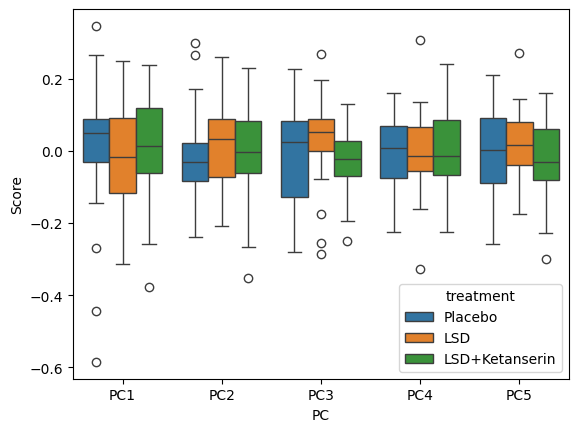

In [ ]:
df_melted = df_scores.melt(
    id_vars=['subject', 'treatment'], 
    value_vars=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    var_name='PC',
    value_name='Score'
)

# Create the boxplot
sns.boxplot(x='PC', y='Score', hue='treatment', data=df_melted)
plt.show()